In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.optimizers import SGD, RMSprop, Adam, AdamW
from tensorflow.keras import regularizers, models, layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import optuna
import wandb
import gc
import cv2

import os
import sqlite3

2026-02-22 14:12:00.463993: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-22 14:12:00.464016: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-22 14:12:00.464942: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-22 14:12:00.469839: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
tf.keras.backend.clear_session()

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("TensorFlow is using the GPU \n", gpus)
else:
    print("No GPU detected.")

TensorFlow is using the GPU 
 [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-02-22 14:12:09.014430: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-02-22 14:12:09.023289: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-02-22 14:12:09.025427: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [3]:
import wandb 

from wandb.integration.keras import WandbMetricsLogger

wandb.require("core")
wandb.login()

wandb: WARNING `wandb.require('core')` is a no-op as it is now the default behavior.
wandb: Currently logged in as: emmdaz (emmdaz-zzz) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
import uproot
from variables_calculator import variables_calculator

file = "/tf/Higgs-Boson-LHC-Collision-Detector/sigfcc_350.root"

data = uproot.open(file)
tree = data["Delphes"]

higgs_b = variables_calculator.inv_m(file, "jet_1", "jet_2", flavor1 = 3, flavor2 = 5)
higgs_b = higgs_b[["pt_1", "pt_2", "eta_1", "eta_2", "phi_1", "phi_2", "event_1", "inv_m"]].copy()
higgs_b.columns = ["PRI_jet_leading_pt", "PRI_jet_subleading_pt", "PRI_jet_leading_eta", "PRI_jet_subleading_eta", "PRI_jet_leading_phi",
                  "PRI_jet_subleading_phi", "event_1", "DER_mass_jet_jet"]

PRI_jet_num = variables_calculator.PRI_jet_num(file)
PRI_jet_all = variables_calculator.PRI_jet_all_pt(file)
met = variables_calculator.met(file)

jets_data = pd.merge(PRI_jet_all, PRI_jet_num, on = "event_1")
jets_data = pd.merge(jets_data, met, on = "event_1")
jets_data = pd.merge(jets_data, higgs_b, on = "event_1")

jets_data["label"] = np.full(len(jets_data), 0)

muon_data = variables_calculator.inv_m(file, "muon", "muon")
electron_data = variables_calculator.inv_m(file, "electron", "electron")
lepton_data = pd.concat([muon_data, electron_data])

lepton_data = lepton_data[["event_1", "inv_m"]].copy()
lepton_data.columns = ["event_1", "DER_mass_lep"]

signal = pd.merge(jets_data, lepton_data, on = "event_1")
signal = signal.drop(columns = ["event_1"])

file = "/tf/Higgs-Boson-LHC-Collision-Detector/bgd240zh.root"

data = uproot.open(file)
tree = data["Delphes"]

higgs_b = variables_calculator.inv_m(file, "jet_1", "jet_2", flavor1 = 3, flavor2 = 5)
higgs_b = higgs_b[["pt_1", "pt_2", "eta_1", "eta_2", "phi_1", "phi_2", "event_1", "inv_m"]].copy()
higgs_b.columns = ["PRI_jet_leading_pt", "PRI_jet_subleading_pt", "PRI_jet_leading_eta", "PRI_jet_subleading_eta", "PRI_jet_leading_phi",
                  "PRI_jet_subleading_phi", "event_1", "DER_mass_jet_jet"]

PRI_jet_num = variables_calculator.PRI_jet_num(file)
PRI_jet_all = variables_calculator.PRI_jet_all_pt(file)
met = variables_calculator.met(file)

jets_data = pd.merge(PRI_jet_all, PRI_jet_num, on = "event_1")
jets_data = pd.merge(jets_data, met, on = "event_1")
jets_data = pd.merge(jets_data, higgs_b, on = "event_1")

jets_data["label"] = np.full(len(jets_data), 1)

muon_data = variables_calculator.inv_m(file, "muon", "muon")
electron_data = variables_calculator.inv_m(file, "electron", "electron")
lepton_data = pd.concat([muon_data, electron_data])

lepton_data = lepton_data[["event_1", "inv_m"]].copy()
lepton_data.columns = ["event_1", "DER_mass_lep"]

noise = pd.merge(jets_data, lepton_data, on = "event_1")
noise = noise.drop(columns = ["event_1"])

sg_sample1 = signal.sample(frac = 0.5, random_state = 4)
sg_sample2 = signal.sample(frac = 0.3, random_state = 4)
sg_sample3 = signal.sample(frac = 0.2, random_state = 4)

bg_sample1 = noise.sample(frac = 0.5, random_state = 4)
bg_sample2 = noise.sample(frac = 0.3, random_state = 4)
bg_sample3 = noise.sample(frac = 0.2, random_state = 4)

train = pd.concat([sg_sample1, bg_sample1])
test = pd.concat([sg_sample2, bg_sample2])
val = pd.concat([sg_sample3, bg_sample3])

# Now we can create the subsets:
X_train, X_test, X_val = train.drop(columns = ["label"]), test.drop(columns = ["label"]), val.drop(columns = ["label"])
y_train, y_test, y_val = train["label"], test["label"], val["label"]

# And we stardardize the data:

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Check the sizes
print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Train size: 39767
Validation size: 15906
Test size: 23860


In [5]:
signal.head()

,PRI_jet_all_pt,PRI_jet_num,PRI_met,PRI_met_phi,PRI_jet_leading_pt,PRI_jet_subleading_pt,PRI_jet_leading_eta,PRI_jet_subleading_eta,PRI_jet_leading_phi,PRI_jet_subleading_phi,DER_mass_jet_jet,label,DER_mass_lep
0,170.760605,3,4.302101,-1.388696,64.256523,36.597229,-0.113773,-1.709504,2.964018,-1.596112,113.084663,0,85.018837
1,304.227875,3,4.129518,2.948901,39.575764,127.212677,-0.525154,0.348251,1.704656,-3.009968,118.901390,0,82.369003
2,283.492126,3,2.992920,1.142674,137.516327,11.906924,0.033779,-1.482367,-1.903679,-0.247148,89.987083,0,92.270065
3,242.444855,3,5.493720,-2.066545,41.898006,102.129112,0.853439,0.485302,2.301678,-1.990217,112.418762,0,83.204475
4,230.607391,3,2.175927,1.302745,63.231850,81.647446,1.091058,0.237706,-0.946260,0.968609,133.423233,0,83.884644


In [6]:
# For the trials we make a smaller train and test sets:

train_small = train.sample(frac = 0.05, random_state = 5)
test_small = test.sample(frac = 0.05, random_state = 5)

X_train_small, X_test_small = train_small.drop(columns = ["label"]), test_small.drop(columns = ["label"])
y_train_small, y_test_small = train_small["label"], test_small["label"]

X_train_small = scaler.fit_transform(X_train_small)
X_test_small = scaler.transform(X_test_small)

# Check the sizes
print("Train size:", len(X_train_small))
print("Test size:", len(X_test_small))

Train size: 1988
Test size: 1193


In [7]:
train_small.head()

,PRI_jet_all_pt,PRI_jet_num,PRI_met,PRI_met_phi,PRI_jet_leading_pt,PRI_jet_subleading_pt,PRI_jet_leading_eta,PRI_jet_subleading_eta,PRI_jet_leading_phi,PRI_jet_subleading_phi,DER_mass_jet_jet,label,DER_mass_lep
54736,314.838654,3,1.193168,2.455253,127.458824,56.494251,-0.297110,0.135516,-0.953704,0.756218,133.294403,0,90.238060
49003,285.497253,3,13.672361,1.746449,101.850990,58.536530,0.442380,0.167290,0.258853,1.843009,111.970200,0,93.139450
74169,272.942261,3,2.611302,1.613100,35.455193,124.250557,0.741615,0.363253,0.459713,2.545727,117.431236,0,93.025505
21369,217.626999,3,53.695290,0.940381,51.100277,30.885263,-0.426417,1.405055,0.935507,0.880771,83.391464,0,92.921883
20127,245.394684,3,0.599459,1.289300,63.611927,65.015717,-1.189577,0.349129,-0.969465,-1.814967,121.109642,0,93.618027


In [8]:
X_train_small.shape

(1988, 12)

In [9]:
# We define a function to create residual blocks (considering a layer regularizer L2)

def residual_block(x, n, activation, dropout, dropout_rate, regularizer, r_2):
        
    residual = x  
        
    if dropout == "y":
        # Main path
        x = layers.Dense(n, activation = activation, kernel_regularizer = regularizers.l2(r_2))(x)
        x = layers.BatchNormalization()(x)
        
        # Intermediate dropout layer
        x = layers.Dropout(dropout_rate)(x)
            
        # Linear layer
        x = layers.Dense(n, kernel_regularizer = regularizers.l2(r_2))(x)
        x = layers.BatchNormalization()(x)
            
    else: 
        # Main path
        x = layers.Dense(n, activation = activation, kernel_regularizer = regularizers.l2(r_2))(x)
        x = layers.BatchNormalization()(x)
            
        # Linear layer
        x = layers.Dense(n, kernel_regularizer = regularizers.l2(r_2))(x)
        x = layers.BatchNormalization()(x)

    # Project shortcut to same dimension
    residual = layers.Dense(n)(residual)

    # Conection residual sum
    x = layers.add([x, residual]) 
    x = layers.Activation(activation)(x)
        
    return x

In [15]:
# We create the function to start the study and optimizarion using Optuna
def objective(trial):

    tf.keras.backend.clear_session()

    inputs = layers.Input(shape = (X_train.shape[1],))
    
    #############################################################################################################
    
    # Optuna suggests activation function for all layers
    activation = trial.suggest_categorical("activation", ["relu", "relu6", "leaky_relu"])
    
    # Optuna suggests regularizer L2 value
    regularizer = "L2"
    r_2 = trial.suggest_float("regularizer_value_2", 1e-7, 1e-5, log = True)
    
    # Optuna suggest the number of layers
    n_layers = trial.suggest_int("N_layers", 15,20)
    
    # Optuna suggests learning rate value and an optimizer
    lr = trial.suggest_float("learning_rate", 2.5e-4, 1e-3, log = True)
    
    optimizer_name = trial.suggest_categorical("optimizer", ["sgd", "adam", "rmsprop", "adamw"])
                              
    if optimizer_name == "sgd":
        optimizer = tf.keras.optimizers.SGD(learning_rate = lr)
    elif optimizer_name == "adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate = lr)
    elif optimizer_name == "rmsprop":
        optimizer = tf.keras.optimizers.RMSprop(learning_rate = lr)
    elif optimizer_name == "adamw":
        optimizer = tf.keras.optimizers.AdamW(learning_rate = lr)              
    
    #############################################################################################################
    
    # First layer

    # Optuna suggest number of neurons for the first layer

    N = trial.suggest_int("N_1st_layer", 128, 256)
    
    x = layers.Dense(N, input_shape = (X_train.shape[1],))(inputs)
    x = layers.Activation(activation)(x)
    x = layers.BatchNormalization()(x)
    
    # Optuna suggests neurons for the residual blocks and if using Dropout block
    
    dropout_per_layer = []
    dropout_percentage_per_layer = []
            
    dropping_out = trial.suggest_categorical("Dropout", ["y", "n"])

    N_per_layer = []
    
    for i in range(n_layers):
        
        n = trial.suggest_int(f"N_{i+1}_layer", 128, 256)
        N_per_layer.append(n)
                              
        dropout_rate = trial.suggest_float(f"Dropout_value_L{i+2}",0.1, 0.15)
        
        # i-th residual block:
        
        # Choosing between Dropout or a regulizer
        
        if dropping_out == "y":
            dropout_percentage_per_layer.append(dropout_rate)
            x = residual_block(x, n, activation, "y", dropout_rate, regularizer, r_2)

        else:
            dropout_percentage_per_layer.append(0.0)
            x = residual_block(x, n, activation, "n", dropout_rate, regularizer, r_2)            
            
    x = layers.Dropout(0.4)(x)  
    outputs = layers.Dense(1, activation = "sigmoid")(x)
    model = models.Model(inputs, outputs)
                              
    model.compile(optimizer = optimizer,
                  loss = "binary_crossentropy",
                  metrics = ["accuracy",
                             tf.keras.metrics.Precision(),
                             tf.keras.metrics.AUC(curve = "ROC"),
                             tf.keras.metrics.AUC(curve = "PR")])
    
    #############################################################################################################

    wandb.init(
        project = "Residual-SnB-Trials-HB-1.0",
        name = f"Trial_{trial.number}",
        reinit = True,
        config = {
            "Units_1": N,
            "Units_per_layer": N_per_layer,
            "activation": activation,
            "n_layers": n_layers,
            "regularizer": regularizer,
            "r_value2": r_2,
            "Dropout": dropping_out, 
            "dropout_percentage_per_layer": dropout_percentage_per_layer,
            "learning_rate": lr,
            "optimizer": optimizer_name        }
    )
    
    #############################################################################################################
    
    """
    Callbacks
    """
    early_stopping = EarlyStopping(monitor = "val_accuracy", patience = 7, restore_best_weights = True)
    lr_reduction = ReduceLROnPlateau(monitor = "val_loss", factor = 0.1, patience = 5)
#     tensorboard_cb = TensorBoard(log_dir = "/workspace/Optuna-Trials/Plant-Pathology-Classificator/tf_debug", histogram_freq = 1, write_graph = True,
#                                  write_images = False)
    
    #############################################################################################################
    
    """
    Creación del modelo
    """
    
    try:
        print(model.summary())
    
        history = model.fit(
            X_train, y_train,
            validation_data = (X_test, y_test),
            batch_size = 32,
            epochs = 200,
            verbose = 1, 
            callbacks = [WandbMetricsLogger(log_freq = 5), early_stopping, lr_reduction]
        )

        val_loss = min(history.history["val_loss"])
        val_accuracy = max(history.history["val_accuracy"])
        
        train_loss = min(history.history["loss"])
        train_accuracy = max(history.history["accuracy"])
    
    except tf.errors.ResourceExhaustedError as e:
        
        print(f"Intento {trial.number} falló debido a: {e}")
        
        tf.keras.backend.clear_session()
        wandb.finish()
        gc.collect()
        
        return float("inf")

    except Exception as e:
        
        print(f"Intento {trial.number} falló. Unexpected error: {e}")
        
        tf.keras.backend.clear_session()
        wandb.finish()
        gc.collect()
        
        return float("inf")
    
    # score = val_loss + 0.1 * (train_loss - val_loss)
    
    score = val_accuracy
    
    # score = train_loss 
    
    tf.keras.backend.clear_session()
    gc.collect()
    wandb.finish()

    return 1-score

In [16]:
study = optuna.create_study(
    study_name = "Residual-Trials_HB-1.0",
    direction = "minimize",
    storage = "sqlite:////workspace/Optuna-Trials/ResNet_SnB_study.db",
    load_if_exists = True
)

study.optimize(objective, n_trials = 500)

[I 2026-02-22 14:18:33,299] Using an existing study with name 'Residual-Trials_HB-1.0' instead of creating a new one.


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 12)]                 0         []                            
                                                                                                  
 dense (Dense)               (None, 237)                  3081      ['input_1[0][0]']             
                                                                                                  
 activation (Activation)     (None, 237)                  0         ['dense[0][0]']               
                                                                                                  
 batch_normalization (Batch  (None, 237)                  948       ['activation[0][0]']          
 Normalization)                                                                               

batch/accuracy,▁▁▁▁▂▃▄▄▃▆▆▆▅▇▇█▇▇███▇██████████████████
batch/auc,▁▄▇▇▇▇▇▇▇███████████▇███████████████████
batch/auc_1,▁▁▁▁▃▄▅▆▆▆▇▇▇▆▆▇▇▇▇▇▇▇▇▇████████████████
batch/batch_step,▁▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▃▃▃▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇█
batch/learning_rate,█████████████████████▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁
batch/loss,█▆▆▆▄▄▃▃▃▃▂▂▄▂▂▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
batch/precision,▁▁▁▆▆▇▇▇▇▇▇▇▇█▇▇████████████████████████
epoch/accuracy,▁▂▂▂▂▃▄▅▅▅▆▇▇▆▆▇▇████████████████████
epoch/auc,▁▅▆▇▇▇▇██████████████████████████████
epoch/auc_1,▁▁▁▂▃▄▅▆▆▇▇▇▇▇▇██████████████████████
+9,...


[I 2026-02-22 14:42:35,424] Trial 4 finished with value: 8.380413055419922e-05 and parameters: {'activation': 'relu', 'regularizer_value_2': 1.6804382898805094e-07, 'N_layers': 15, 'learning_rate': 0.00034096072157915983, 'optimizer': 'adam', 'N_1st_layer': 237, 'Dropout': 'y', 'N_1_layer': 232, 'Dropout_value_L2': 0.13234013376970072, 'N_2_layer': 181, 'Dropout_value_L3': 0.1105853363379972, 'N_3_layer': 130, 'Dropout_value_L4': 0.14427539507580495, 'N_4_layer': 184, 'Dropout_value_L5': 0.13608202003853764, 'N_5_layer': 217, 'Dropout_value_L6': 0.11524167241278727, 'N_6_layer': 185, 'Dropout_value_L7': 0.10681911793790112, 'N_7_layer': 170, 'Dropout_value_L8': 0.13198483154562068, 'N_8_layer': 182, 'Dropout_value_L9': 0.1308921214728522, 'N_9_layer': 147, 'Dropout_value_L10': 0.12637427315677555, 'N_10_layer': 255, 'Dropout_value_L11': 0.13579665511943093, 'N_11_layer': 229, 'Dropout_value_L12': 0.11048406777300922, 'N_12_layer': 178, 'Dropout_value_L13': 0.14010932541499987, 'N_13_la

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 12)]                 0         []                            
                                                                                                  
 dense (Dense)               (None, 154)                  2002      ['input_1[0][0]']             
                                                                                                  
 activation (Activation)     (None, 154)                  0         ['dense[0][0]']               
                                                                                                  
 batch_normalization (Batch  (None, 154)                  616       ['activation[0][0]']          
 Normalization)                                                                               

...

batch/accuracy,▁▂▃▃▄▅▅▅▅▅▆▅▆▇▆▇▇▇▇▇▇▇▇▇▇▇▇█▇▆▇▇▇▇▇▆▇███
batch/auc,▁▅▄▆▇▇▇▇█▇████████████▁█████████████████
batch/auc_1,▁▁▁▁▁▄▅▄▄▄▄▁▅▆▆▇█▇▇▇█▇▇▇██▇▇▇████▇▇▇▇▇██
batch/batch_step,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
batch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
batch/loss,███▅▄▃▄▄▃▃▃▂▂▂▃▂▂▂▂▁▂▂▂▂▂▂▂▂▁▁▁▂▂▂▂▂▃▃▁▁
batch/precision,▁▃▃▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇█▇▇▇▇▇▇▇██▇▇▇▇▇█▇██▇
epoch/accuracy,▁▃▄▅▆▅▆▇▅▇██▇█▇█▆██
epoch/auc,▁▆▆▇▇▇██▇██████████
epoch/auc_1,▁▃▄▅▆▆▇█▆███████▇██
+9,...


[I 2026-02-22 19:50:07,393] Trial 25 finished with value: 0.00020956993103027344 and parameters: {'activation': 'leaky_relu', 'regularizer_value_2': 1.686744194360206e-07, 'N_layers': 17, 'learning_rate': 0.00035109246058480034, 'optimizer': 'adam', 'N_1st_layer': 241, 'Dropout': 'y', 'N_1_layer': 233, 'Dropout_value_L2': 0.1139280041886625, 'N_2_layer': 255, 'Dropout_value_L3': 0.1268370806979008, 'N_3_layer': 190, 'Dropout_value_L4': 0.12996579369844835, 'N_4_layer': 172, 'Dropout_value_L5': 0.10301031715157173, 'N_5_layer': 181, 'Dropout_value_L6': 0.11064869301834687, 'N_6_layer': 143, 'Dropout_value_L7': 0.12316199560802249, 'N_7_layer': 154, 'Dropout_value_L8': 0.10615668229813584, 'N_8_layer': 192, 'Dropout_value_L9': 0.13384710708066186, 'N_9_layer': 173, 'Dropout_value_L10': 0.13753329916886228, 'N_10_layer': 166, 'Dropout_value_L11': 0.13693273332770978, 'N_11_layer': 198, 'Dropout_value_L12': 0.11544827355868746, 'N_12_layer': 190, 'Dropout_value_L13': 0.13504929251098496, '

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 12)]                 0         []                            
                                                                                                  
 dense (Dense)               (None, 222)                  2886      ['input_1[0][0]']             
                                                                                                  
 activation (Activation)     (None, 222)                  0         ['dense[0][0]']               
                                                                                                  
 batch_normalization (Batch  (None, 222)                  888       ['activation[0][0]']          
 Normalization)                                                                               

[W 2026-02-22 19:50:27,831] Trial 26 failed with parameters: {'activation': 'leaky_relu', 'regularizer_value_2': 5.781151143174953e-07, 'N_layers': 16, 'learning_rate': 0.00027875280002106795, 'optimizer': 'adam', 'N_1st_layer': 222, 'Dropout': 'y', 'N_1_layer': 190, 'Dropout_value_L2': 0.10007478642879694, 'N_2_layer': 222, 'Dropout_value_L3': 0.11582226288071573, 'N_3_layer': 204, 'Dropout_value_L4': 0.12174240718804394, 'N_4_layer': 197, 'Dropout_value_L5': 0.10919378090586819, 'N_5_layer': 136, 'Dropout_value_L6': 0.11732518497920512, 'N_6_layer': 174, 'Dropout_value_L7': 0.10994042093682313, 'N_7_layer': 179, 'Dropout_value_L8': 0.12832327001360042, 'N_8_layer': 227, 'Dropout_value_L9': 0.14521639440961637, 'N_9_layer': 151, 'Dropout_value_L10': 0.14485393880334088, 'N_10_layer': 140, 'Dropout_value_L11': 0.13060333862210885, 'N_11_layer': 179, 'Dropout_value_L12': 0.10674196404235303, 'N_12_layer': 170, 'Dropout_value_L13': 0.1199311049588338, 'N_13_layer': 154, 'Dropout_value_L1

KeyboardInterrupt: 

In [18]:
activation = "leaky_relu"
units1 = 219
units_per_1ayer = [211, 159, 144, 153, 130, 142, 128, 245, 207, 235, 195, 240, 145, 146, 233, 213, 197, 216]
dropout = [0.106947284116077, 0.10819977128063964, 0.12289087039768846, 0.1016884190924875, 0.12476779547127996, 0.1244463837089424,
           0.11235300265467205, 0.1394620805935431, 0.14411858860476412, 0.14164669940676178, 0.11657521156554118, 0.10900573045793582,
           0.1223589766273066, 0.13236255646980274, 0.13316619160051676, 0.11998568256267018, 0.1231237542676506, 0.10951438125960496]

r2 = 0.00000024206951828158
eta = 0.00030300708895906033

tf.keras.backend.clear_session()
inputs = layers.Input(shape = (X_train.shape[1],))
x = layers.Dense(units1, input_shape = (X_train.shape[1],))(inputs)
x = layers.Activation(activation)(x)
x = layers.BatchNormalization()(x)

for i in range(len(units_per_1ayer)):
    n = units_per_1ayer[i]
    dropout_rate = dropout[i]
    x = residual_block(x, n, activation, "y", dropout_rate, "L2", r2)            
            
x = layers.Dropout(0.4)(x)  
outputs = layers.Dense(1, activation = "sigmoid")(x)
model = models.Model(inputs, outputs)

model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate = eta),
              loss = "binary_crossentropy",
              metrics = ["accuracy",
                         tf.keras.metrics.Precision(),
                         tf.keras.metrics.AUC(curve = "ROC"),
                         tf.keras.metrics.AUC(curve = "PR")])

wandb.init(project = "Residual-SnB(AllData)-Trials-1.0",
           name = "Trial_1",
           reinit = True,
           config = {
               "Units_1": units1,
               "Units_per_layer": units_per_1ayer,
               "Droput": "yes",
               "Dropout_per_layer": dropout,
               "activation": activation,
               "n_layers": len(units_per_1ayer),
               "regularizer": "R2",
               "r_value2": r2,
               "learning_rate": eta,
               "optimizer": "Adam"})

print(model.summary())

early_stopping = EarlyStopping(monitor = "val_accuracy", patience = 7, restore_best_weights = True)
lr_reduction = ReduceLROnPlateau(monitor = "val_loss", factor = 0.1, patience = 5)

history = model.fit(X_train, y_train,
                    validation_data = (X_test, y_test),
                    batch_size = 32,
                    epochs = 200,
                    verbose = 1, 
                    callbacks = [WandbMetricsLogger(log_freq = 5), early_stopping, lr_reduction]
                   )

val_loss = min(history.history["val_loss"])
val_accuracy = max(history.history["val_accuracy"])
        
train_loss = min(history.history["loss"])
train_accuracy = max(history.history["accuracy"])

tf.keras.backend.clear_session()
gc.collect()
wandb.finish()

batch/accuracy,▁█
batch/auc,▁█
batch/auc_1,▁█
batch/batch_step,▁█
batch/learning_rate,▁▁
batch/loss,█▁
batch/precision,▁▁
batch/accuracy,0.78646
batch/auc,0.20545
batch/auc_1,0.01228
batch/batch_step,5


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 12)]                 0         []                            
                                                                                                  
 dense (Dense)               (None, 219)                  2847      ['input_1[0][0]']             
                                                                                                  
 activation (Activation)     (None, 219)                  0         ['dense[0][0]']               
                                                                                                  
 batch_normalization (Batch  (None, 219)                  876       ['activation[0][0]']          
 Normalization)                                                                               

batch/accuracy,▁▁▁▁▂▄▆▇▆▇▇▇▅▆▇█▇▇▇▇▇▇▇███▇███▆▇▇██████▇
batch/auc,▁▇▇▇▇▇███▇██████████████████████████████
batch/auc_1,▁▁▁▁▂▄▅▇▆▆▇▇▇▆▇█▆▅▇▇▇████████▇█████████▇
batch/batch_step,▁▁▁▁▁▁▂▂▂▂▂▂▂▃▃▄▄▄▄▄▄▄▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇███
batch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
batch/loss,█▅▄▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▃▃▃▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁
batch/precision,▁▃▃▃▅▆▆▆▇▇▇▇▇▇▇▇██▆▇▇▇█▇▇██▇██▇██████▁▇▇
epoch/accuracy,▁▂▃▄▄▆▆▅▆▇▇▇▆▇▇██▇██▇▇███▇██████
epoch/auc,▁▆▇▇▇▇▇▇████████████████████████
epoch/auc_1,▁▂▄▅▅▇▇▆▇▇▇█▇▇███▇███████▇██████
+9,...


In [19]:
model.save("ResNet-SnB-Higgs_B-Classificator.keras")

In [20]:
model_ev = keras.models.load_model("ResNet-SnB-Higgs_B-Classificator.keras")

loss, accuracy, precision, auc, auc_1 = model_ev.evaluate(X_val, y_val, verbose = 1)

print(f"Test Loss: {loss:}")
print(f"Test Accuracy: {accuracy:}")

498/498 [==============================] - 4s 5ms/step - loss: 0.0028 - accuracy: 0.9997 - precision: 1.0000 - auc: 1.0000 - auc_1: 0.9966        
Test Loss: 0.0028453944250941277
Test Accuracy: 0.9997485280036926


498/498 [==============================] - 2s 4ms/step


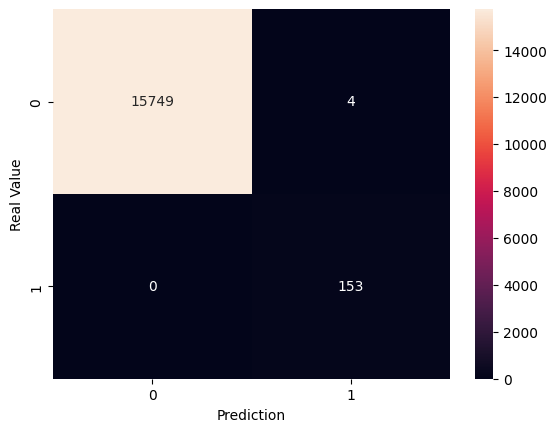

In [21]:
from sklearn.metrics import confusion_matrix

y_pred = model_ev.predict(X_val)
y_pred_classes = (y_pred > 0.5).astype("int32")

cm = confusion_matrix(y_pred_classes, y_val)
sns.heatmap(cm, annot = True, fmt = "d", cmap = "rocket")

plt.xlabel("Prediction")
plt.ylabel("Real Value")
plt.show()